 **Task:** Build, train, and evaluate a Convolutional Neural Network (CNN) to classify images of waste into distinct categories. The dataset features 10 distinct classes of garbage with a total of 13,348 images, distributed as follows:
- Metal: 930
- Glass: 1736
- Biological: 699
- Paper: 1336
- Battery: 756
- Trash: 453
- Cardboard: 1411
- Shoes: 1449
- Clothes: 1892
- Plastic: 1597

**Business Problem:** Garbage disposal is a huge problem in today's world. As the population grows, the waste generated increases and proper treatment and disposal of the generated waste is important to ensure negligible harm to the environment.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
import os
import random

import tensorflow as tf

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp -r "/content/drive/MyDrive/CNN Dataset" /content/

In [4]:
data_dir = "/content/CNN Dataset"

In [5]:
print(os.listdir(data_dir))

['cardboard', 'battery', 'trash', 'shoes', 'glass', 'clothes', 'plastic', 'biological', 'paper', 'metal']


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [7]:
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 9811 images belonging to 10 classes.


In [32]:
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2448 images belonging to 10 classes.


In [9]:
print(train_data.class_indices)

{'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


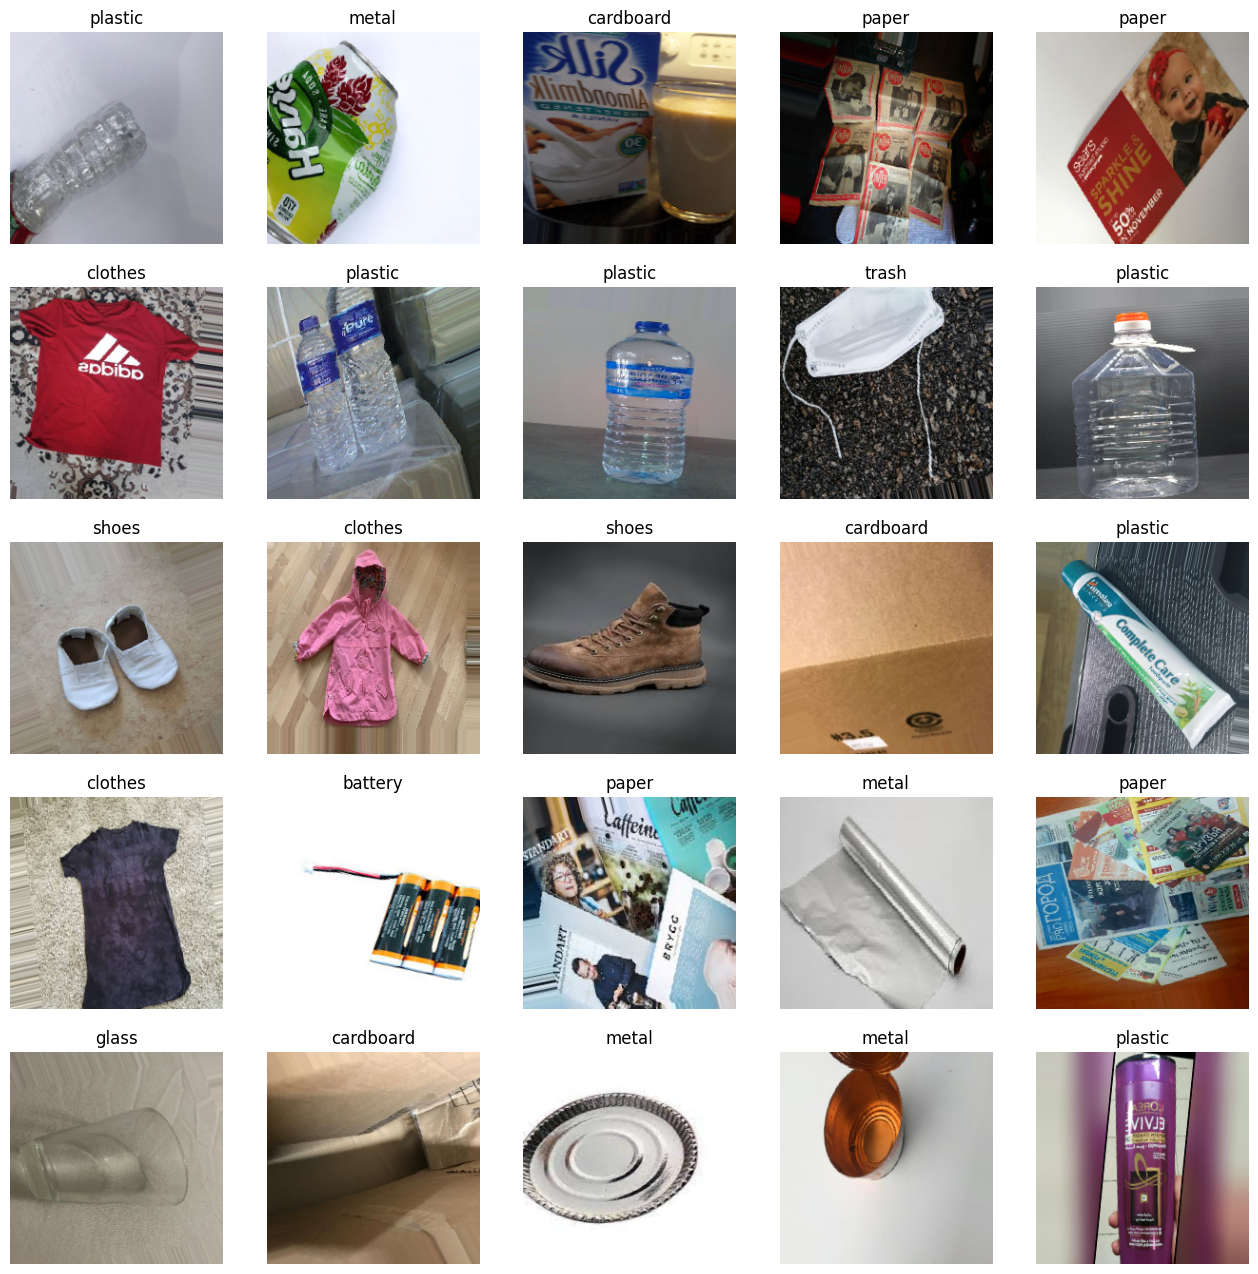

In [10]:
images, labels = next(train_data)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(16,16))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')

    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])

plt.show()

In [14]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [15]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
for layer in base_model.layers:
    layer.trainable = False

In [17]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "mobilenet_best.h5",
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.6278 - loss: 1.1393

307/307 ━━━━━━━━━━━━━━━━━━━━ 238s 703ms/step - accuracy: 0.7371 - loss: 0.7946 - val_accuracy: 0.8468 - val_loss: 0.4376
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.8212 - loss: 0.5217

307/307 ━━━━━━━━━━━━━━━━━━━━ 174s 567ms/step - accuracy: 0.8275 - loss: 0.5090 - val_accuracy: 0.8725 - val_loss: 0.3774
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8560 - loss: 0.4358

307/307 ━━━━━━━━━━━━━━━━━━━━ 172s 561ms/step - accuracy: 0.8520 - loss: 0.4421 - val_accuracy: 0.8824 - val_loss: 0.3595
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 175s 571ms/step - accuracy: 0.8674 - loss: 0.4004 - val_accuracy: 0.8819 - val_loss: 0.3419
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 175s 569ms/step - accuracy: 0.8689 - loss: 0.3858 - val_accuracy: 0.8787 - val_loss: 0.3525
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.8835 - loss: 0.3498

307/307 ━━━━━━━━━━━━━━━━━━━━ 174s 568ms/step - accuracy: 0.8833 - loss: 0.3486 - val_accuracy: 0.8962 - val_loss: 0.3246
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 176s 574ms/step - accuracy: 0.8836 - loss: 0.3401 - val_accuracy: 0.8901 - val_loss: 0.3272
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 176s 573ms/step - accuracy: 0.8869 - loss: 0.3257 - val_accuracy: 0.8926 - val_loss: 0.3124
Epoch 9/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 175s 572ms/step - accuracy: 0.8952 - loss: 0.3065 - val_accuracy: 0.8860 - val_loss: 0.3261
Epoch 10/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 175s 570ms/step - accuracy: 0.8990 - loss: 0.3030 - val_accuracy: 0.8881 - val_loss: 0.3345


In [20]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [22]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 215s 645ms/step - accuracy: 0.8000 - loss: 0.6386 - val_accuracy: 0.8946 - val_loss: 0.3168
Epoch 2/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 177s 575ms/step - accuracy: 0.8543 - loss: 0.4570 - val_accuracy: 0.8926 - val_loss: 0.3268
Epoch 3/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 189s 617ms/step - accuracy: 0.8705 - loss: 0.3859 - val_accuracy: 0.8950 - val_loss: 0.3283
Epoch 4/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 188s 613ms/step - accuracy: 0.8850 - loss: 0.3578 - val_accuracy: 0.9036 - val_loss: 0.3044
Epoch 5/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 184s 601ms/step - accuracy: 0.8873 - loss: 0.3365 - val_accuracy: 0.8942 - val_loss: 0.3230


In [27]:
loss, acc = model.evaluate(val_data)
print(f"Final Accuracy: {acc*100:.2f}%")

39/39 ━━━━━━━━━━━━━━━━━━━━ 36s 924ms/step - accuracy: 0.9073 - loss: 0.2990
Final Accuracy: 90.73%


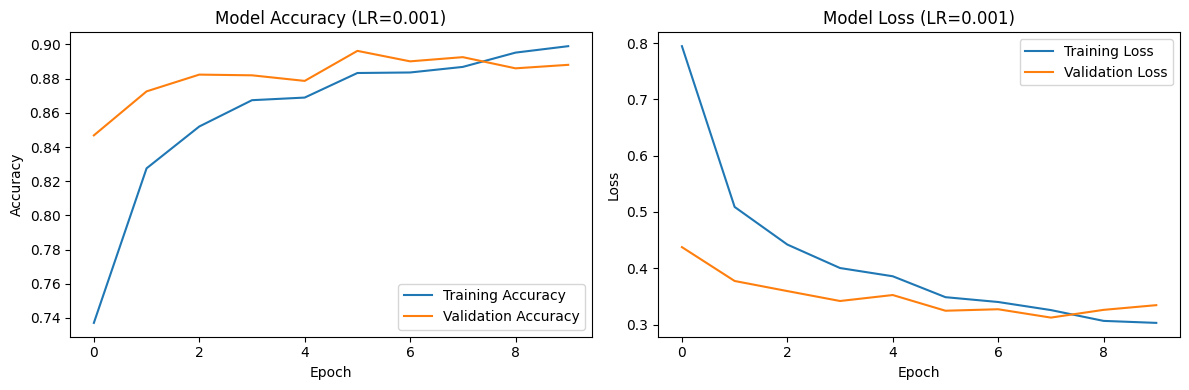

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Model Accuracy (LR=0.001)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Model Loss (LR=0.001)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
val_data.reset()

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

39/39 ━━━━━━━━━━━━━━━━━━━━ 38s 967ms/step


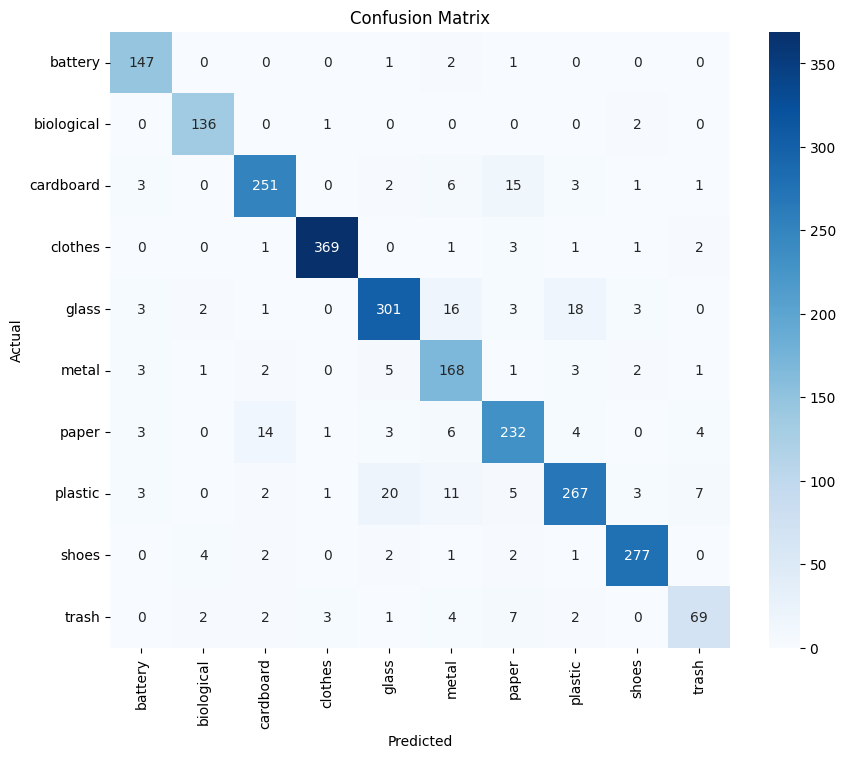

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

     battery       0.91      0.97      0.94       151
  biological       0.94      0.98      0.96       139
   cardboard       0.91      0.89      0.90       282
     clothes       0.98      0.98      0.98       378
       glass       0.90      0.87      0.88       347
       metal       0.78      0.90      0.84       186
       paper       0.86      0.87      0.87       267
     plastic       0.89      0.84      0.86       319
       shoes       0.96      0.96      0.96       289
       trash       0.82      0.77      0.79        90

    accuracy                           0.91      2448
   macro avg       0.90      0.90      0.90      2448
weighted avg       0.91      0.91      0.91      2448



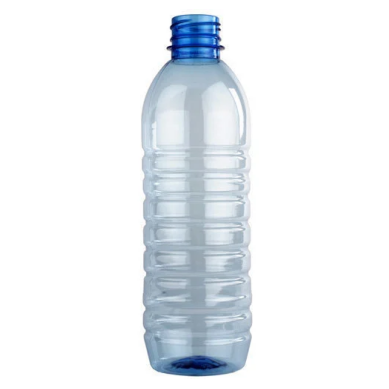

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted: plastic


In [40]:
from tensorflow.keras.preprocessing import image
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('test.webp')

plt.imshow(img)
plt.axis('off')
plt.show()
img_path = "test.webp"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
pred_class = class_names[np.argmax(prediction)]

print("Predicted:", pred_class)